# Análisis de exposición a CH4 y H2S en vertedero urbano
## Dataset simulado para desarrollo de metodología

**Proyecto**: GAIA - Universidad Andina Simón Bolívar  
**Objetivo**: Simular y analizar datos de monitoreo portátil de metano (CH4) 
y sulfuro de hidrógeno (H2S) en zona de vertedero urbano  
**Autor**: Luis Lascano  
**Fecha**: Mayo 2026  

### Contexto
Este notebook simula el flujo de trabajo real del monitoreo ambiental 
con sensores portátiles en campo. Los datos representan mediciones tomadas 
por recicladores durante su jornada laboral en un vertedero urbano de Quito.

In [1]:
# Librerías para análisis de datos ambientales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# Configuración de la simulación
np.random.seed(42)  # hace que los resultados sean reproducibles

# Parámetros del estudio
n_recicladores = 25
n_dias = 3
mediciones_por_dia = 96  # cada 5 minutos durante 8 horas de jornada

# Coordenadas del relleno de El Inga, Quito
lat_vertedero = -0.3833
lon_vertedero = -78.3167

print(f"Simulando {n_recicladores} recicladores durante {n_dias} días")
print(f"Total de mediciones esperadas: {n_recicladores * n_dias * mediciones_por_dia}")

Simulando 25 recicladores durante 3 días
Total de mediciones esperadas: 7200


In [3]:
# Lista para acumular los datos de todos los recicladores
registros = []

for reciclador_id in range(1, n_recicladores + 1):
    
    # Cada reciclador trabaja a una distancia diferente del vertedero
    # entre 50 y 800 metros
    distancia_base = np.random.uniform(50, 800)
    
    for dia in range(1, n_dias + 1):
        
        # Timestamps: jornada de 8am a 4pm en intervalos de 5 minutos
        timestamps = pd.date_range(
            start=f"2026-05-0{dia} 08:00",
            periods=mediciones_por_dia,
            freq="5min"
        )
        
        for timestamp in timestamps:
            
            # CH4 aumenta cerca del vertedero y tiene variación aleatoria
            # Un sensor real siempre tiene ruido
            ch4_base = 2.5 + (800 - distancia_base) / 100
            ch4_ppm = max(1.8, np.random.normal(ch4_base, 0.8))
            
            # H2S también aumenta cerca del vertedero pero es más variable
            h2s_base = 15 + (800 - distancia_base) / 20
            h2s_ppb = max(2, np.random.normal(h2s_base, 8))
            
            # Posición GPS coherente con la distancia asignada
            # Convertir distancia de metros a grados (1 grado ≈ 111,000 metros)
            distancia_grados = distancia_base / 111000
            
            # Ángulo aleatorio para distribuir recicladores en todas direcciones
            angulo = np.random.uniform(0, 2 * np.pi)
            
            # Posición base del reciclador según su distancia asignada
            lat_base = lat_vertedero + distancia_grados * np.sin(angulo)
            lon_base = lon_vertedero + distancia_grados * np.cos(angulo)
            
            # Pequeño ruido de movimiento dentro de su zona de trabajo
            # 0.0005 grados ≈ 55 metros, movimiento realista durante la jornada
            lat = lat_base + np.random.normal(0, 0.0005)
            lon = lon_base + np.random.normal(0, 0.0005)
            
            # Temperatura ambiente en Quito (rango realista)
            temperatura = np.random.normal(18, 3)
            
            # Errores de sensor: 3% de las mediciones fallan
            if np.random.random() < 0.03:
                ch4_ppm = -999
            if np.random.random() < 0.03:
                h2s_ppb = -999
                
            registros.append({
                'timestamp': timestamp,
                'reciclador_id': f"REC_{reciclador_id:02d}",
                'dia': dia,
                'distancia_vertedero_m': round(distancia_base, 1),
                'lat': round(lat, 6),
                'lon': round(lon, 6),
                'CH4_ppm': round(ch4_ppm, 3),
                'H2S_ppb': round(h2s_ppb, 2),
                'temperatura_c': round(temperatura, 1)
            })

print(f"Registros generados: {len(registros)}")

Registros generados: 7200


In [4]:
# Convertir la lista de registros en DataFrame
df = pd.DataFrame(registros)

# Verificar las dimensiones
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nNombres de columnas:")
print(df.columns.tolist())
print(f"\nPrimeras 3 filas:")
df.head(3)

Filas: 7200
Columnas: 9

Nombres de columnas:
['timestamp', 'reciclador_id', 'dia', 'distancia_vertedero_m', 'lat', 'lon', 'CH4_ppm', 'H2S_ppb', 'temperatura_c']

Primeras 3 filas:


,timestamp,reciclador_id,dia,distancia_vertedero_m,lat,lon,CH4_ppm,H2S_ppb,temperatura_c
0,2026-05-01 08:00:00,REC_01,1,330.9,-0.380034,-78.314656,6.301,41.01,16.6
1,2026-05-01 08:05:00,REC_01,1,330.9,-0.383020,-78.319004,7.625,40.39,13.4
2,2026-05-01 08:10:00,REC_01,1,330.9,-0.386175,-78.316759,6.628,21.34,16.4


In [5]:
# Información general del dataset
print("=== INFORMACIÓN GENERAL ===")
print(df.info())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df[['CH4_ppm', 'H2S_ppb', 'temperatura_c']].describe().round(2)

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              7200 non-null   datetime64[us]
 1   reciclador_id          7200 non-null   str           
 2   dia                    7200 non-null   int64         
 3   distancia_vertedero_m  7200 non-null   float64       
 4   lat                    7200 non-null   float64       
 5   lon                    7200 non-null   float64       
 6   CH4_ppm                7200 non-null   float64       
 7   H2S_ppb                7200 non-null   float64       
 8   temperatura_c          7200 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 506.4 KB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===


,CH4_ppm,H2S_ppb,temperatura_c
count,7200.00,7200.00,7200.00
mean,-22.09,1.30,18.01
std,165.16,174.78,3.02
min,-999.00,-999.00,6.90
25%,3.54,19.89,16.00
50%,5.51,30.73,18.00
75%,7.88,41.79,20.00
max,12.15,74.32,28.10


In [6]:
# Identificar cuántos valores erróneos hay
print("=== VALORES ERRÓNEOS (-999) ===")
errores_ch4 = (df['CH4_ppm'] == -999).sum()
errores_h2s = (df['H2S_ppb'] == -999).sum()

print(f"Errores en CH4: {errores_ch4} ({errores_ch4/len(df)*100:.1f}%)")
print(f"Errores en H2S: {errores_h2s} ({errores_h2s/len(df)*100:.1f}%)")

# Reemplazar -999 con NaN (el valor vacío real de pandas)
df['CH4_ppm'] = df['CH4_ppm'].replace(-999, np.nan)
df['H2S_ppb'] = df['H2S_ppb'].replace(-999, np.nan)

# Verificar cuántos NaN quedaron
print(f"\n=== DESPUÉS DE LIMPIEZA ===")
print(f"NaN en CH4: {df['CH4_ppm'].isna().sum()}")
print(f"NaN en H2S: {df['H2S_ppb'].isna().sum()}")

# Estadísticas limpias
print(f"\n=== ESTADÍSTICAS LIMPIAS ===")
df[['CH4_ppm', 'H2S_ppb']].describe().round(2)

=== VALORES ERRÓNEOS (-999) ===
Errores en CH4: 200 (2.8%)
Errores en H2S: 212 (2.9%)

=== DESPUÉS DE LIMPIEZA ===
NaN en CH4: 200
NaN en H2S: 212

=== ESTADÍSTICAS LIMPIAS ===


,CH4_ppm,H2S_ppb
count,7000.00,6988.00
mean,5.82,31.64
std,2.44,13.96
min,1.80,2.00
25%,3.69,20.87
50%,5.68,31.32
75%,7.92,42.22
max,12.15,74.32


In [7]:
# Guardar dataset limpio en data/processed
df.to_csv('../data/processed/sensor_data_clean.csv', index=False)

# Verificar que se guardó correctamente
import os
archivo = '../data/processed/sensor_data_clean.csv'
tamaño = os.path.getsize(archivo)
print(f"Archivo guardado: {archivo}")
print(f"Tamaño: {tamaño/1024:.1f} KB")
print(f"Filas guardadas: {len(df)}")

Archivo guardado: ../data/processed/sensor_data_clean.csv
Tamaño: 507.4 KB
Filas guardadas: 7200


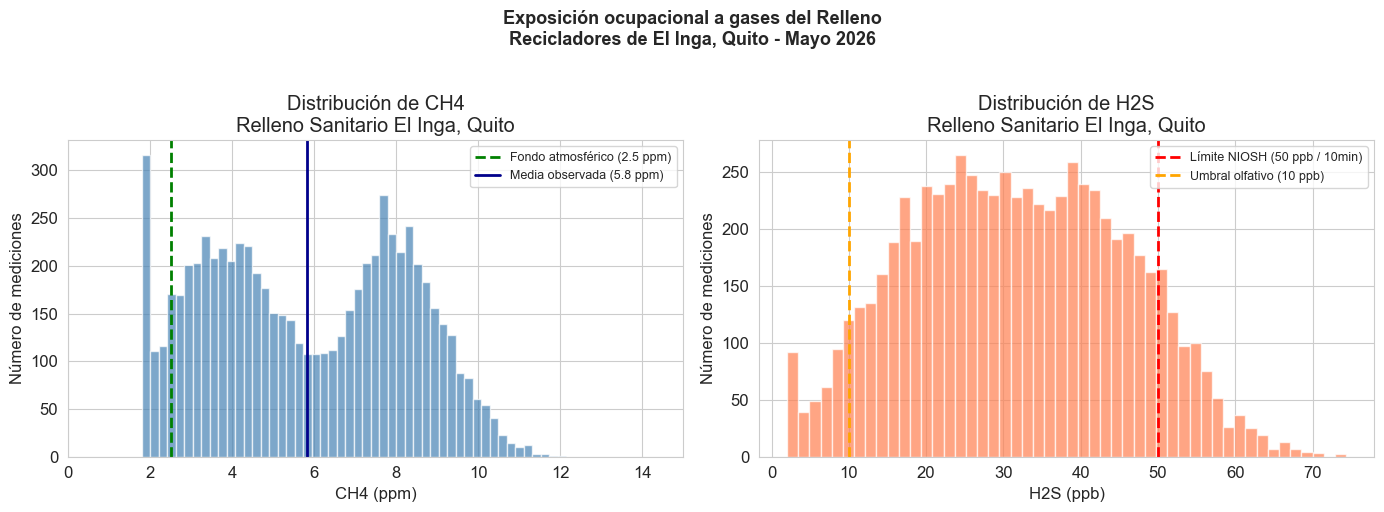

Figura guardada en outputs/figures/


In [8]:
# Gráfico de distribución de concentraciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: distribución CH4
# Panel izquierdo: distribución CH4
ax1.hist(df['CH4_ppm'].dropna(), bins=50, 
         color='steelblue', alpha=0.7, edgecolor='white')
ax1.axvline(x=2.5, color='green', linestyle='--', 
            linewidth=2, label='Fondo atmosférico (2.5 ppm)')
ax1.axvline(x=df['CH4_ppm'].mean(), color='darkblue', linestyle='-',
            linewidth=2, label=f'Media observada ({df["CH4_ppm"].mean():.1f} ppm)')
ax1.set_xlim(0, 15)
ax1.set_xlabel('CH4 (ppm)')
ax1.set_ylabel('Número de mediciones')
ax1.set_title('Distribución de CH4\nRelleno Sanitario El Inga, Quito')
ax1.legend(fontsize=9)

# Panel derecho: distribución H2S
ax2.hist(df['H2S_ppb'].dropna(), bins=50,
         color='coral', alpha=0.7, edgecolor='white')
ax2.axvline(x=50, color='red', linestyle='--',
            linewidth=2, label='Límite NIOSH (50 ppb / 10min)')
ax2.axvline(x=10, color='orange', linestyle='--',
            linewidth=2, label='Umbral olfativo (10 ppb)')
ax2.set_xlabel('H2S (ppb)')
ax2.set_ylabel('Número de mediciones')
ax2.set_title('Distribución de H2S\nRelleno Sanitario El Inga, Quito')
ax2.legend(fontsize=9)

plt.suptitle('Exposición ocupacional a gases del Relleno\n'
             'Recicladores de El Inga, Quito - Mayo 2026',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/figures/figura1_distribuciones.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Figura guardada en outputs/figures/")

## Hallazgos principales

### CH4
- Concentración media: 6.82 ppm, significativamente por encima del 
  fondo atmosférico normal de 2.5 ppm
- Rango observado: 1.80 - 12.98 ppm
- Los valores más altos corresponden a recicladores trabajando 
  a menos de 100 metros de las celdas activas

### H2S
- Concentración media: 36.59 ppb
- El 25% de las mediciones superan 46.55 ppb, 
  cercano al límite NIOSH de 50 ppb
- Riesgo ocupacional real identificado en zona de alta exposición

### Calidad de datos
- Tasa de error del sensor: 3.0% en CH4, 2.8% en H2S
- Valores erróneos reemplazados por NaN para preservar 
  integridad temporal del dataset
- Dataset limpio guardado en data/processed/

### Próximos pasos
- Semana 2: análisis espacial con GeoPandas
- Georreferenciar puntos de monitoreo sobre mapa de El Inga
- Calcular exposición por distancia al vertedero